# Notebook 3: Measures of Dispersion

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What is Dispersion?

Dispersion (spread) tells us how far the values in a dataset are from each other and from the center. Central tendency gives the "typical value", and dispersion tells us how reliable that typical value is.

**Analogy:** Two cricket batsmen both average 50 runs. Batsman A scores 48, 49, 50, 51, 52 every match (consistent). Batsman B scores 10, 30, 50, 70, 90 (unpredictable). The mean is the same, but the spread is very different.

**Measures covered:** Range, Variance, Standard Deviation, Quartiles, Percentiles, IQR, Coefficient of Variation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
batsman_a = [48, 49, 50, 51, 52]
batsman_b = [10, 30, 50, 70, 90]

print("Mean A:", np.mean(batsman_a), "| Mean B:", np.mean(batsman_b))

Mean A: 50.0 | Mean B: 50.0


**Explanation:** Both datasets have the same mean (50), but B is much more spread out.

**Interpretation:** The mean alone can mislead us. We need a measure of spread to understand the data fully.

## 1. Range

**Definition:** Range is the difference between the maximum and minimum values. It is the simplest measure of spread.

**Formula:**

$$Range = X_{max} - X_{min}$$

**Numerical Example:** Data = 10, 20, 30, 40, 50
Range = 50 - 10 = **40**

**Business Example:** A shop checks the difference between the highest and lowest daily sales to see how much sales fluctuate.

**AI/ML Example:** Min-Max scaling uses the range (max - min) to scale features between 0 and 1. A quick range check also helps spot wrong values (for example, age = 500).

In [3]:
print("Range of A:", max(batsman_a) - min(batsman_a))
print("Range of B:", max(batsman_b) - min(batsman_b))

# Using NumPy
print("Range of B (numpy):", np.ptp(batsman_b))

Range of A: 4
Range of B: 80
Range of B (numpy): 80


**Explanation:** We subtract the minimum from the maximum. `np.ptp()` (peak to peak) does the same.

**Interpretation:** Range of A is 4 and range of B is 80, so B is far more spread out. **Limitation:** Range uses only two values (max and min), so one outlier can change it completely.

## 2. Variance

**Definition:** Variance is the average of the squared distances of each value from the mean. It measures how far values are spread around the mean.

**Formula:**

Population variance:

$$\sigma^2 = \frac{\sum_{i=1}^{N} (x_i - \mu)^2}{N}$$

Sample variance:

$$s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}$$

(For a sample we divide by n - 1, called Bessel's correction, because a sample usually underestimates the true spread.)

**Numerical Example:** Data = 2, 4, 4, 4, 5, 5, 7, 9
Mean = 40 / 8 = 5
Squared differences = 9, 1, 1, 1, 0, 0, 4, 16, and their sum = 32
Population variance = 32 / 8 = **4**
Sample variance = 32 / 7 = **4.571**

**Business Example:** A bank measures the variance of monthly returns of an investment. Higher variance means higher risk.

**AI/ML Example:** Variance is used in PCA (directions with the highest variance are kept), in feature selection (features with near-zero variance are removed), and in the bias-variance tradeoff of models.

In [4]:
data = [2, 4, 4, 4, 5, 5, 7, 9]

# Manual calculation
mean = sum(data) / len(data)
squared_diff = [(x - mean) ** 2 for x in data]
pop_var_manual = sum(squared_diff) / len(data)
sample_var_manual = sum(squared_diff) / (len(data) - 1)

# Using NumPy
pop_var = np.var(data)             # ddof=0 (population)
sample_var = np.var(data, ddof=1)  # ddof=1 (sample)

print("Mean:", mean)
print("Population variance (manual):", pop_var_manual)
print("Sample variance (manual)    :", round(sample_var_manual, 4))
print("Population variance (numpy) :", pop_var)
print("Sample variance (numpy)     :", round(sample_var, 4))

Mean: 5.0
Population variance (manual): 4.0
Sample variance (manual)    : 4.5714
Population variance (numpy) : 4.0
Sample variance (numpy)     : 4.5714


**Explanation:** We find the mean, square each difference from the mean, add them, and divide by N (population) or N - 1 (sample). In NumPy, `ddof` (delta degrees of freedom) controls this.

**Interpretation:** Variance is 4 for the population and about 4.57 for the sample. A larger variance means more spread. **Limitation:** Variance is in squared units (rupees squared), which is hard to interpret. Standard deviation fixes this.

## 3. Standard Deviation

**Definition:** Standard deviation is the square root of the variance. It tells us, on average, how far values are from the mean, in the same unit as the data.

**Formula:**

$$\sigma = \sqrt{\sigma^2} \qquad s = \sqrt{s^2}$$

**Numerical Example:** From the previous data, variance = 4
Standard deviation = √4 = **2**

**Business Example:** A factory fills 500 ml bottles. A standard deviation of 2 ml means most bottles are within about 2 ml of 500. A low value means good quality control.

**AI/ML Example:** Standardization (Z-score scaling) divides by the standard deviation. Outlier detection uses it (Z-score method), and it is used to initialize neural network weights.

In [5]:
pop_std = np.std(data)
sample_std = np.std(data, ddof=1)

print("Population std:", pop_std)
print("Sample std    :", round(sample_std, 4))

# Compare consistent vs inconsistent batsman
print("\nStd of A:", round(np.std(batsman_a), 2))
print("Std of B:", round(np.std(batsman_b), 2))

Population std: 2.0
Sample std    : 2.1381

Std of A: 1.41
Std of B: 28.28


**Explanation:** `np.std()` gives the square root of the variance. We then compare Batsman A and Batsman B.

**Interpretation:** The standard deviation of A is about 1.41 and B is about 28.28. Both average 50, but B is far less consistent. Low standard deviation means values are close to the mean, and high means they are spread out.

## 4. Quartiles

**Definition:** Quartiles divide sorted data into four equal parts.
- **Q1 (25th percentile):** 25% of values are below it
- **Q2 (50th percentile):** the median
- **Q3 (75th percentile):** 75% of values are below it

**Formula (position, as used by NumPy):**

$$\text{position} = (n - 1) \times p$$

where p = 0.25, 0.50, or 0.75. If the position is not a whole number, we interpolate between the two nearest values.

**Numerical Example:** Data = 12, 15, 17, 18, 20, 22, 25, 27, 30, 35, 90 (n = 11)
Q1 position = 10 × 0.25 = 2.5, between 17 and 18, so **Q1 = 17.5**
Q2 = 6th value = **22**
Q3 position = 7.5, between 27 and 30, so **Q3 = 28.5**

*(Different textbooks use slightly different methods, so small differences are normal.)*

**Business Example:** A company splits employees into four salary groups (quartiles) to design pay bands.

**AI/ML Example:** Quartiles are used to build box plots and to detect outliers (IQR method). They are also used for binning a feature into groups (`pd.qcut`).

In [6]:
values = [12, 15, 17, 18, 20, 22, 25, 27, 30, 35, 90]

q1 = np.percentile(values, 25)
q2 = np.percentile(values, 50)
q3 = np.percentile(values, 75)

print("Q1:", q1)
print("Q2 (Median):", q2)
print("Q3:", q3)

# Using pandas
print("\n", pd.Series(values).describe())

Q1: 17.5
Q2 (Median): 22.0
Q3: 28.5

 count    11.000000
mean     28.272727
std      21.568917
min      12.000000
25%      17.500000
50%      22.000000
75%      28.500000
max      90.000000
dtype: float64


**Explanation:** `np.percentile()` finds the value below which a given percentage of data lies. `describe()` also shows Q1, median and Q3.

**Interpretation:** 25% of values are below 17.5, 50% are below 22 and 75% are below 28.5. Notice the big gap between the max (90) and Q3 (28.5), which hints at an outlier.

## 5. Percentiles

**Definition:** The k-th percentile is the value below which k% of the data falls. Quartiles are special percentiles (25th, 50th, 75th).

**Formula:**

$$\text{position} = (n - 1) \times \frac{k}{100}$$

**Numerical Example:** For the same data (n = 11), the 90th percentile position = 10 × 0.90 = 9, which is the 10th value, so **P90 = 35**.

**Business Example:** A student scoring in the 95th percentile in an entrance exam performed better than 95% of students. Delivery apps track the 95th percentile of delivery time to set promises.

**AI/ML Example:** Model latency is monitored with P95 and P99 in production. Percentiles are also used to clip extreme values (winsorization) during data cleaning.

In [7]:
percentiles = [10, 25, 50, 75, 90]
results = np.percentile(values, percentiles)

for p, r in zip(percentiles, results):
    print(f"P{p}: {r}")

# Percentile rank of a value
print("\nPercentile rank of 25:", stats.percentileofscore(values, 25))

P10: 15.0
P25: 17.5
P50: 22.0
P75: 28.5
P90: 35.0

Percentile rank of 25: 63.63636363636364


**Explanation:** We calculate several percentiles in one call. `percentileofscore()` does the reverse: it finds what percentile a given value is at.

**Interpretation:** P90 = 35 means 90% of values are 35 or less. Percentiles are better than the mean to describe "how most users experience something".

## 6. Interquartile Range (IQR)

**Definition:** IQR is the range of the middle 50% of the data. It ignores the lowest 25% and highest 25%, so it is not affected by outliers.

**Formula:**

$$IQR = Q_3 - Q_1$$

Outlier fences:

$$Lower = Q_1 - 1.5 \times IQR \qquad Upper = Q_3 + 1.5 \times IQR$$

**Numerical Example:** Q1 = 17.5, Q3 = 28.5
IQR = 28.5 - 17.5 = **11**
Lower fence = 17.5 - 16.5 = 1
Upper fence = 28.5 + 16.5 = 45
The value **90 is above 45, so it is an outlier**.

**Business Example:** A real estate company uses IQR to remove unusually priced houses (data entry errors) before finding the average price in an area.

**AI/ML Example:** The IQR method is a standard way to detect and treat outliers during data cleaning. `RobustScaler` in scikit-learn also scales features using the median and IQR.

In [8]:
q1 = np.percentile(values, 25)
q3 = np.percentile(values, 75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = [v for v in values if v < lower or v > upper]

print("Q1:", q1, "| Q3:", q3)
print("IQR:", iqr)
print("Lower fence:", lower, "| Upper fence:", upper)
print("Outliers:", outliers)

# Using SciPy
print("IQR (scipy):", stats.iqr(values))

Q1: 17.5 | Q3: 28.5
IQR: 11.0
Lower fence: 1.0 | Upper fence: 45.0
Outliers: [90]
IQR (scipy): 11.0


**Explanation:** We find Q1, Q3, the IQR and the two fences. Any value outside the fences is marked as an outlier.

**Interpretation:** The IQR is 11, and 90 lies beyond the upper fence (45), so it is an outlier. Unlike range and standard deviation, IQR stays stable even with this extreme value.

## 7. Coefficient of Variation (CV)

**Definition:** CV is the standard deviation expressed as a percentage of the mean. It measures relative spread, so we can compare datasets with different units or different scales.

**Formula:**

$$CV = \frac{\sigma}{\mu} \times 100\%$$

**Numerical Example:**
Stock A: mean = 100, std ≈ 7.07, so CV ≈ **7.07%**
Stock B: mean = 50, std ≈ 14.14, so CV ≈ **28.28%**
Stock B has a higher standard deviation and is also riskier relative to its price.

**Business Example:** An investor compares two stocks with different prices. CV shows risk per unit of return, which standard deviation alone cannot do.

**AI/ML Example:** CV helps to compare variability across features with different units (height in cm vs weight in kg) and to find features that are too unstable or too constant.

In [9]:
stock_a = [90, 95, 100, 105, 110]
stock_b = [30, 40, 50, 60, 70]

def cv(data):
    return np.std(data) / np.mean(data) * 100

print("Stock A -> Mean:", np.mean(stock_a), "| Std:", round(np.std(stock_a), 2), "| CV:", round(cv(stock_a), 2), "%")
print("Stock B -> Mean:", np.mean(stock_b), "| Std:", round(np.std(stock_b), 2), "| CV:", round(cv(stock_b), 2), "%")

# Using SciPy
print("\nCV (scipy) A:", round(stats.variation(stock_a) * 100, 2), "%")

Stock A -> Mean: 100.0 | Std: 7.07 | CV: 7.07 %
Stock B -> Mean: 50.0 | Std: 14.14 | CV: 28.28 %

CV (scipy) A: 7.07 %


**Explanation:** We divide the standard deviation by the mean and multiply by 100. Stock B has a bigger std and also a smaller mean, so its CV is much higher.

**Interpretation:** Stock A varies about 7% around its mean, and Stock B about 28%. Lower CV means more consistent. **Use CV when comparing spread across different units or different means.**

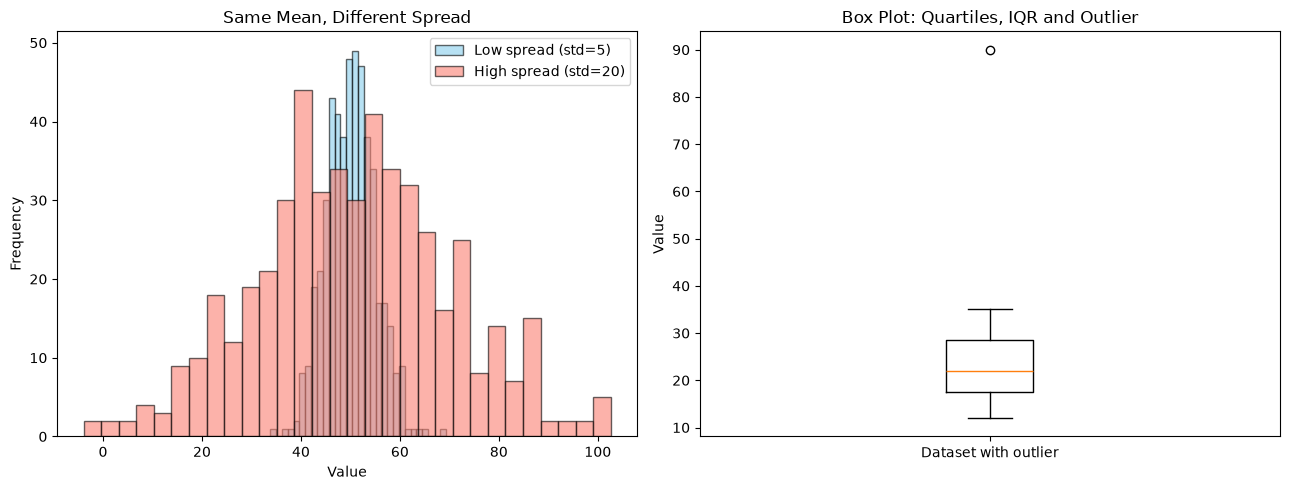

In [11]:
np.random.seed(42)
low_spread = np.random.normal(loc=50, scale=5, size=500)
high_spread = np.random.normal(loc=50, scale=20, size=500)

# 'values' Cell 15-la define aanathu. Illa na inga thirumba define pannu
values = [12, 15, 17, 18, 20, 22, 25, 27, 30, 35, 90]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograms
axes[0].hist(low_spread, bins=30, alpha=0.6, label="Low spread (std=5)", color="skyblue", edgecolor="black")
axes[0].hist(high_spread, bins=30, alpha=0.6, label="High spread (std=20)", color="salmon", edgecolor="black")
axes[0].set_title("Same Mean, Different Spread")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Box plot showing quartiles and outliers
axes[1].boxplot(values)
axes[1].set_xticklabels(["Dataset with outlier"])
axes[1].set_title("Box Plot: Quartiles, IQR and Outlier")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

**Explanation:** The left chart compares two datasets with the same mean but different standard deviations. The right box plot shows Q1, median, Q3, whiskers and the outlier (90).

**Interpretation:** Low spread data forms a tall, narrow shape, and high spread data is wide and flat. In the box plot, the box is the IQR (middle 50%), the line inside is the median, and the dot above the whisker is the outlier.

## Summary: Which Measure to Use?

| Measure | What it tells | Affected by outliers? | Best used when |
|---|---|---|---|
| Range | Max - Min | Very much | Quick, rough idea |
| Variance | Average squared spread | Yes | Mathematical work, PCA |
| Standard Deviation | Average spread (same unit) | Yes | Normal-like data |
| Quartiles | 25/50/75% points | No | Skewed data, box plots |
| Percentiles | Any k% point | No | Rankings, latency (P95) |
| IQR | Spread of middle 50% | No | Outlier detection |
| CV | Relative spread (%) | Yes | Comparing different scales |

## Advantages
- Shows how reliable or consistent the data is, which the mean cannot do
- Helps compare variability between datasets
- Helps detect outliers and unusual patterns
- Forms the base for Z-score, normal distribution, PCA and hypothesis testing

## Limitations
- Range depends only on two values
- Variance and standard deviation are sensitive to outliers
- Variance is in squared units, which is hard to interpret
- CV cannot be used when the mean is zero or close to zero
- Percentiles and quartiles may differ slightly depending on the calculation method